In [1]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("hospital.csv")

In [3]:
df

,Patient_ID,Age,Gender,Admission_Type,Primary_Diagnosis_ICD10,Systolic_BP_mmHg,Diastolic_BP_mmHg,Heart_Rate_bpm,BMI,Blood_Sugar_mgdL,WBC_Count_k_uL,Comorbidities_Count,Charlson_Comorbidity_Index,Length_of_Stay_Days,Total_Treatment_Cost_USD,Readmission_Risk_Score_1to10,Readmitted_30d_Flag,Mortality_Outcome_Flag
0,PT-0001,63,Male,Emergency,N17.9 (Acute Kidney Failure),117,70,73,26.0,105,7.4,0,1,21,62772.46,4,False,False
1,PT-0002,17,Female,Emergency,G30.9 (Alzheimer's),128,81,45,20.0,96,4.8,1,1,10,23302.04,2,True,True
2,PT-0003,73,Female,Urgent,F32.9 (Major Depression),112,68,73,24.0,134,11.2,1,3,5,11272.04,5,False,True
3,PT-0004,33,Female,Emergency,C34.9 (Bronchus/Lung Cancer),119,75,84,23.0,142,3.5,5,7,16,46458.63,10,True,False
4,PT-0005,84,Male,Urgent,I21.4 (Myocardial Infarction),153,95,85,23.3,81,5.7,1,1,10,27345.32,4,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,PT-0496,91,Male,Emergency,F32.9 (Major Depression),120,71,60,26.1,141,8.2,1,1,10,34226.22,5,True,False
496,PT-0497,17,Female,Trauma,G30.9 (Alzheimer's),143,80,73,25.3,149,10.2,0,2,11,36198.83,2,False,True
497,PT-0498,43,Male,Emergency,N17.9 (Acute Kidney Failure),125,75,56,41.4,140,8.1,3,4,11,27387.44,5,True,False
498,PT-0499,59,Other,Emergency,E11.9 (Type 2 Diabetes),125,70,89,27.1,103,6.9,1,1,6,18545.56,2,False,False


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\2165445885.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


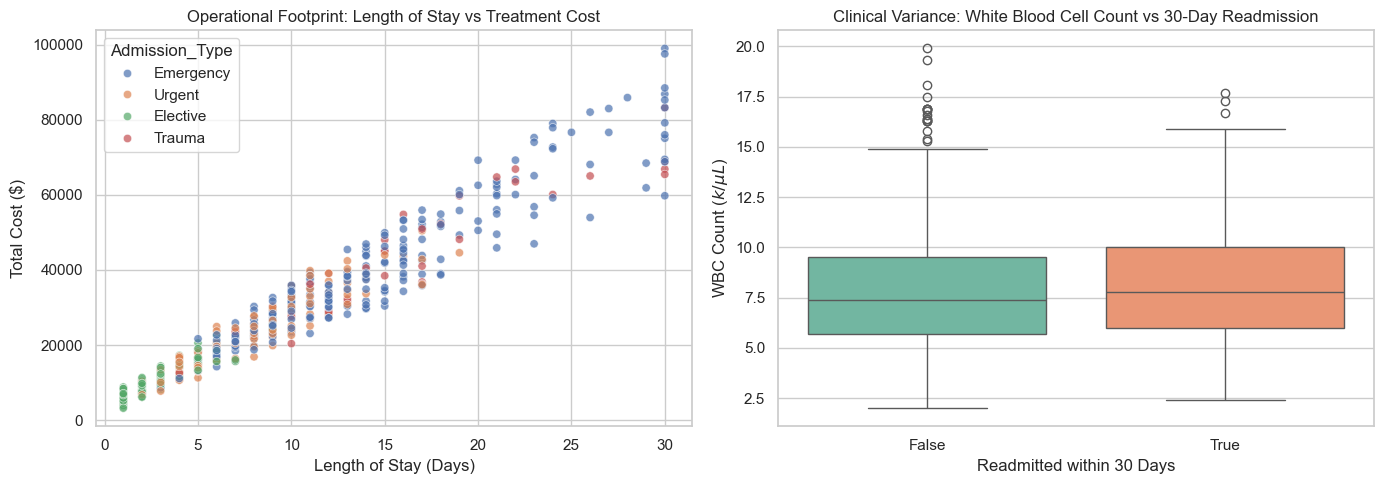

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Plot 1: Length of Stay vs Total Cost colored by Admission Type
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df, 
    x="Length_of_Stay_Days", 
    y="Total_Treatment_Cost_USD", 
    hue="Admission_Type", 
    alpha=0.7
)
plt.title("Operational Footprint: Length of Stay vs Treatment Cost")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Cost ($)")

# Plot 2: Vital Distribution based on readmission outcomes
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df, 
    x="Readmitted_30d_Flag", 
    y="WBC_Count_k_uL", 
    palette="Set2"
)
plt.title("Clinical Variance: White Blood Cell Count vs 30-Day Readmission")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("WBC Count ($k/\mu L$)")

plt.tight_layout()
plt.savefig("eda_visualizations.png", dpi=300)
plt.show()

DEMOGRAPHIC OVERVIEW
               Age  Gender
count   500.000000     500
unique         NaN       3
top            NaN  Female
freq           NaN     255
mean     46.758000     NaN
std      27.864679     NaN
min       1.000000     NaN
25%      23.000000     NaN
50%      47.000000     NaN
75%      70.000000     NaN
max      95.000000     NaN


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\912722499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[1], palette='pastel')


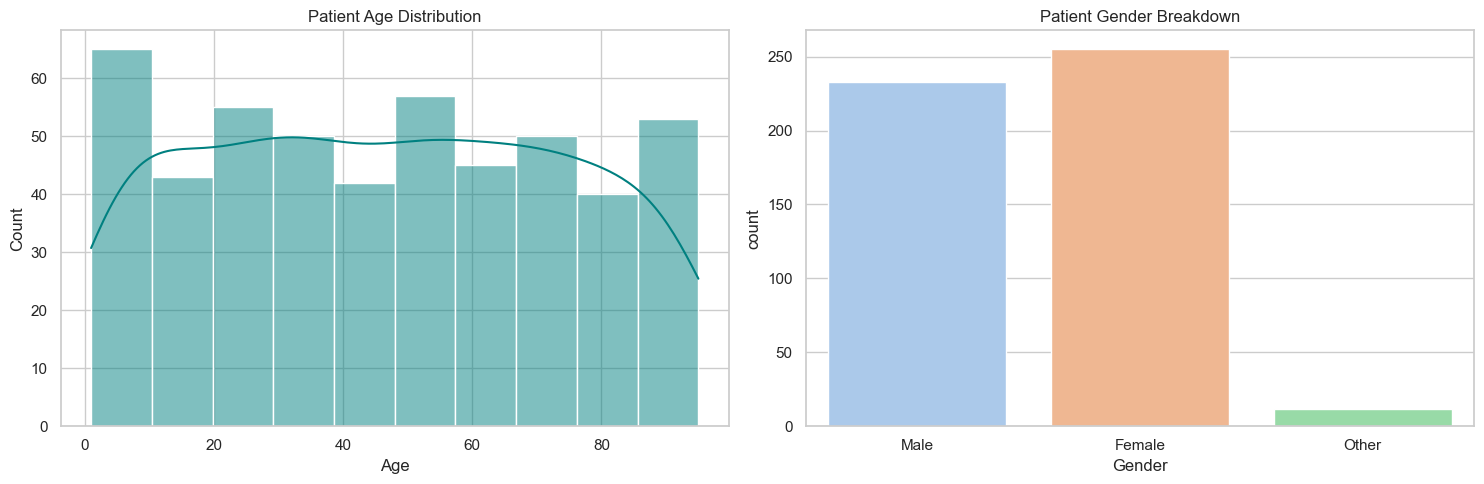

In [5]:
print("DEMOGRAPHIC OVERVIEW")
print(df[['Age', 'Gender']].describe(include='all'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='Age', kde=True, ax=axes[0], color='teal')
axes[0].set_title('Patient Age Distribution')

sns.countplot(data=df, x='Gender', ax=axes[1], palette='pastel')
axes[1].set_title('Patient Gender Breakdown')
plt.tight_layout()
plt.show()

TOP DIAGNOSES BY FREQUENCY
Primary_Diagnosis_ICD10
J44.9 (COPD)                     63
G30.9 (Alzheimer's)              61
I50.9 (Heart Failure)            61
E11.9 (Type 2 Diabetes)          57
C34.9 (Bronchus/Lung Cancer)     55
F32.9 (Major Depression)         54
A41.9 (Sepsis)                   54
N17.9 (Acute Kidney Failure)     51
I21.4 (Myocardial Infarction)    44
Name: count, dtype: int64


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\777752311.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Primary_Diagnosis_ICD10', order=top_diagnoses.index, palette='viridis')


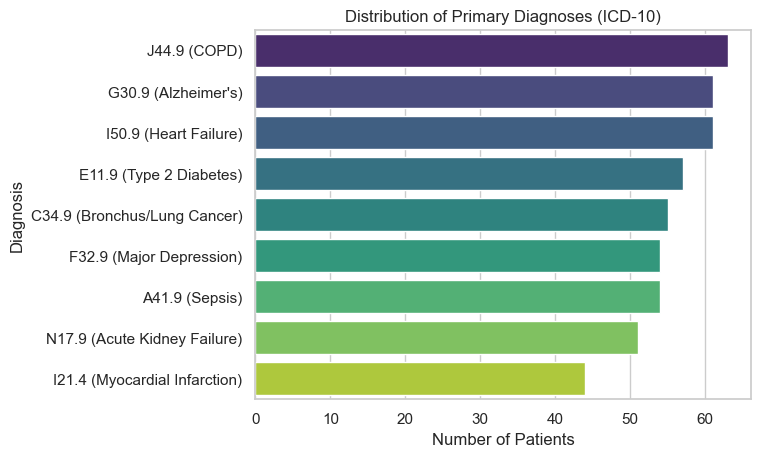

In [6]:
print("TOP DIAGNOSES BY FREQUENCY")
top_diagnoses = df['Primary_Diagnosis_ICD10'].value_counts()
print(top_diagnoses)

sns.countplot(data=df, y='Primary_Diagnosis_ICD10', order=top_diagnoses.index, palette='viridis')
plt.title('Distribution of Primary Diagnoses (ICD-10)')
plt.xlabel('Number of Patients')
plt.ylabel('Diagnosis')
plt.show()

OPERATIONAL METRICS BY ADMISSION TYPE
                Length_of_Stay_Days  Total_Treatment_Cost_USD
Admission_Type                                               
Elective                   2.912281              10890.823509
Emergency                 14.195652              39961.062304
Trauma                    16.027027              43357.908108
Urgent                     8.016807              23608.851008


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\2123485427.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Admission_Type', y='Length_of_Stay_Days', ax=axes[0], palette='Set2')
C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\2123485427.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Admission_Type', y='Total_Treatment_Cost_USD', ax=axes[1], palette='Set2', errorbar=None)


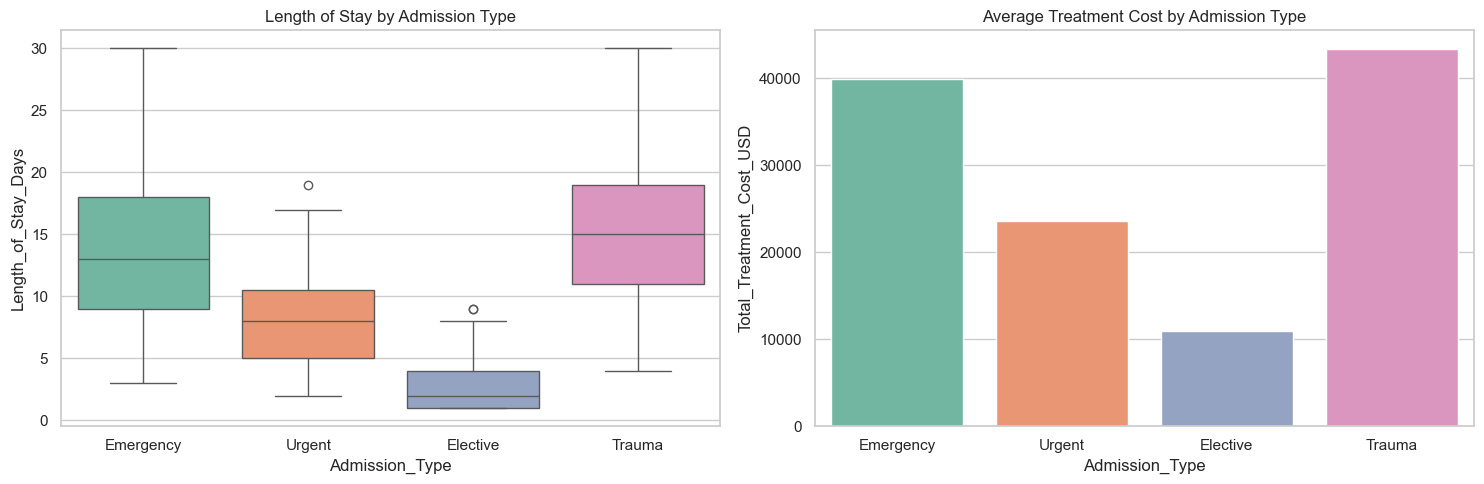

In [7]:
print("OPERATIONAL METRICS BY ADMISSION TYPE")
operational_summary = df.groupby('Admission_Type')[['Length_of_Stay_Days', 'Total_Treatment_Cost_USD']].mean()
print(operational_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Admission_Type', y='Length_of_Stay_Days', ax=axes[0], palette='Set2')
axes[0].set_title('Length of Stay by Admission Type')

sns.barplot(data=df, x='Admission_Type', y='Total_Treatment_Cost_USD', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Average Treatment Cost by Admission Type')
plt.tight_layout()
plt.show()

CORRELATION MATRIX OF CLINICAL METRICS


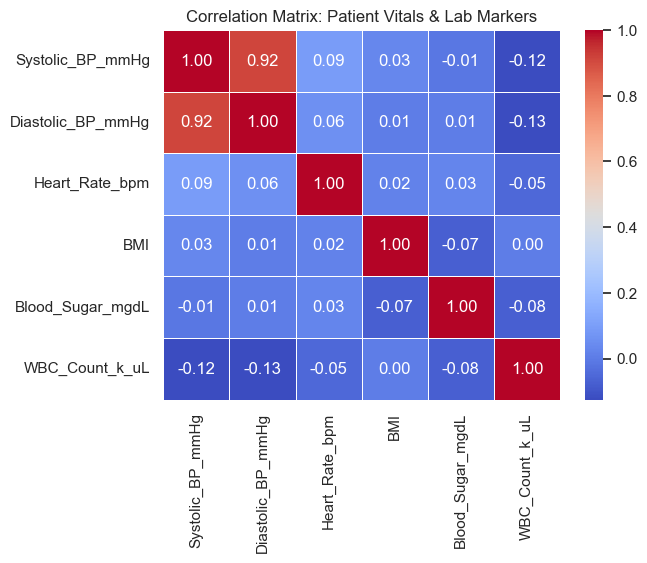

In [8]:
print("CORRELATION MATRIX OF CLINICAL METRICS")
# Select numerical clinical features
vitals_labs = ['Systolic_BP_mmHg', 'Diastolic_BP_mmHg', 'Heart_Rate_bpm', 'BMI', 'Blood_Sugar_mgdL', 'WBC_Count_k_uL']
corr_matrix = df[vitals_labs].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Patient Vitals & Lab Markers')
plt.show()

READMISSION RISK VS COMORBIDITY INDEX
Average Charlson Comorbidity Index by Readmission Status:
Readmitted_30d_Flag
False    2.469512
True     3.145349
Name: Charlson_Comorbidity_Index, dtype: float64


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\53631061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Readmitted_30d_Flag', y='Charlson_Comorbidity_Index', palette='Set1')


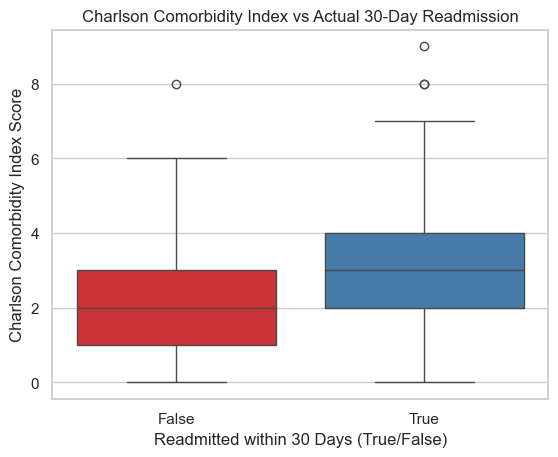

In [9]:
print("READMISSION RISK VS COMORBIDITY INDEX")
readmit_summary = df.groupby('Readmitted_30d_Flag')['Charlson_Comorbidity_Index'].mean()
print("Average Charlson Comorbidity Index by Readmission Status:")
print(readmit_summary)

sns.boxplot(data=df, x='Readmitted_30d_Flag', y='Charlson_Comorbidity_Index', palette='Set1')
plt.title('Charlson Comorbidity Index vs Actual 30-Day Readmission')
plt.xlabel('Readmitted within 30 Days (True/False)')
plt.ylabel('Charlson Comorbidity Index Score')
plt.show()

 DAILY TREATMENT COST INTENSITY BY DIAGNOSIS
Primary_Diagnosis_ICD10
C34.9 (Bronchus/Lung Cancer)     3429.728840
J44.9 (COPD)                     3409.467715
E11.9 (Type 2 Diabetes)          3329.268665
N17.9 (Acute Kidney Failure)     3295.188503
I21.4 (Myocardial Infarction)    3253.793288
I50.9 (Heart Failure)            3233.680482
G30.9 (Alzheimer's)              3169.442183
A41.9 (Sepsis)                   3150.065397
F32.9 (Major Depression)         3116.198615
Name: Cost_Per_Day, dtype: float64


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\1395144105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


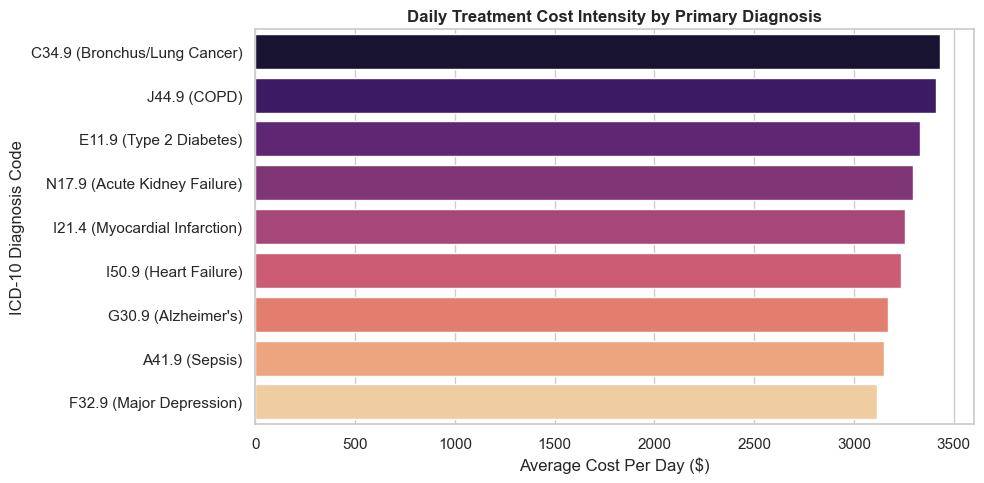

In [10]:
print(" DAILY TREATMENT COST INTENSITY BY DIAGNOSIS")
# Feature engineering: calculate expenditure normalized per day
df['Cost_Per_Day'] = df['Total_Treatment_Cost_USD'] / df['Length_of_Stay_Days']
mean_daily_cost = df.groupby('Primary_Diagnosis_ICD10')['Cost_Per_Day'].mean().sort_values(ascending=False)
print(mean_daily_cost)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df, 
    y='Primary_Diagnosis_ICD10', 
    x='Cost_Per_Day', 
    palette='magma', 
    errorbar=None,
    order=mean_daily_cost.index
)
plt.title('Daily Treatment Cost Intensity by Primary Diagnosis', fontsize=12, fontweight='bold')
plt.xlabel('Average Cost Per Day ($)')
plt.ylabel('ICD-10 Diagnosis Code')
plt.tight_layout()
plt.show()

 RISK SCORE VALIDATION MATRIX
                              Readmitted_30d_Flag  Mortality_Outcome_Flag
Readmission_Risk_Score_1to10                                             
1                                        9.230769                3.076923
2                                       19.047619                7.936508
3                                       24.705882                8.235294
4                                       30.769231                4.395604
5                                       41.428571               21.428571
6                                       50.000000               14.285714
7                                       60.526316               18.421053
8                                       72.222222               11.111111
9                                       66.666667               33.333333
10                                     100.000000               12.500000


<Figure size 1000x500 with 0 Axes>

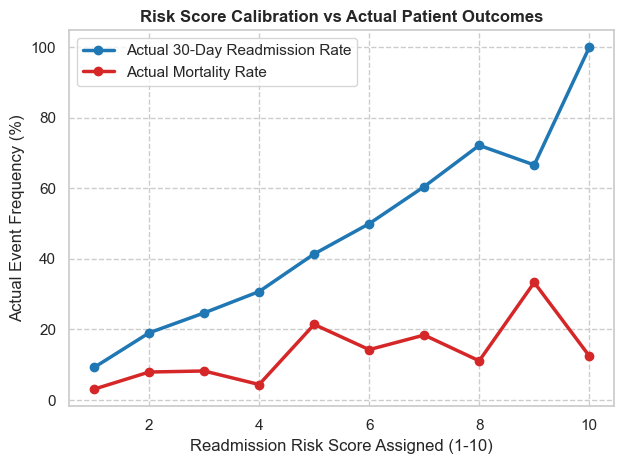

In [11]:
print(" RISK SCORE VALIDATION MATRIX")
# Calculate historical percentage probabilities per risk score tier
risk_calibration = df.groupby('Readmission_Risk_Score_1to10')[['Readmitted_30d_Flag', 'Mortality_Outcome_Flag']].mean() * 100
print(risk_calibration)

plt.figure(figsize=(10, 5))
risk_calibration.plot(kind='line', marker='o', linewidth=2.5, color=['#1f77b4', '#d62728'])
plt.title('Risk Score Calibration vs Actual Patient Outcomes', fontsize=12, fontweight='bold')
plt.xlabel('Readmission Risk Score Assigned (1-10)')
plt.ylabel('Actual Event Frequency (%)')
plt.grid(True, linestyle='--')
plt.legend(['Actual 30-Day Readmission Rate', 'Actual Mortality Rate'])
plt.tight_layout()
plt.show()

LAB MARKER DISTRIBUTION BY DIAGNOSIS CATEGORIES


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\4023560932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


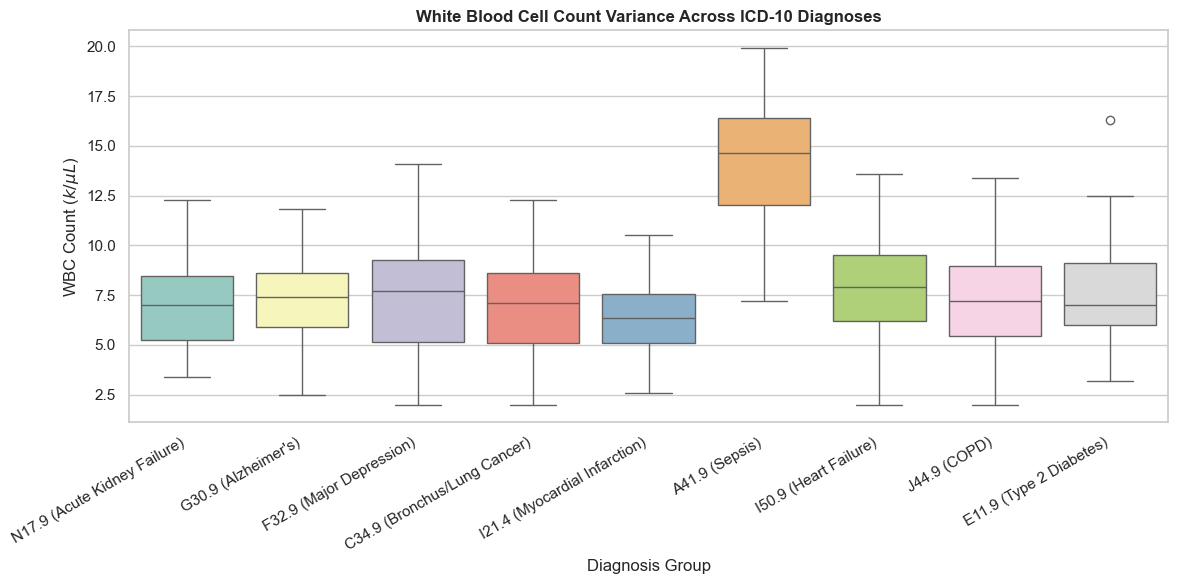

In [12]:
print("LAB MARKER DISTRIBUTION BY DIAGNOSIS CATEGORIES")
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='Primary_Diagnosis_ICD10', 
    y='WBC_Count_k_uL', 
    palette='Set3'
)
plt.title('White Blood Cell Count Variance Across ICD-10 Diagnoses', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('WBC Count ($k/\mu L$)')
plt.xlabel('Diagnosis Group')
plt.tight_layout()
plt.show()

HEMODYNAMIC SCATTER MATRIX BY AGE COHORTS 


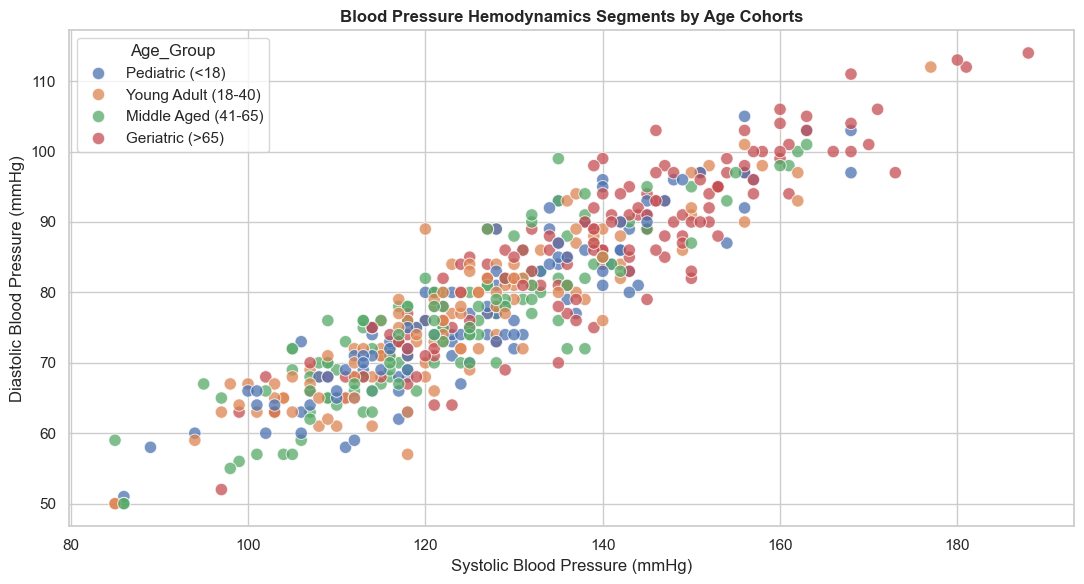

In [13]:
print("HEMODYNAMIC SCATTER MATRIX BY AGE COHORTS ")
# Bin the continuous age feature into specific life stages
df['Age_Group'] = pd.cut(
    df['Age'], 
    bins=[0, 18, 40, 65, 100], 
    labels=['Pediatric (<18)', 'Young Adult (18-40)', 'Middle Aged (41-65)', 'Geriatric (>65)']
)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df, 
    x='Systolic_BP_mmHg', 
    y='Diastolic_BP_mmHg', 
    hue='Age_Group', 
    alpha=0.75, 
    s=80, 
    palette='deep'
)
plt.title('Blood Pressure Hemodynamics Segments by Age Cohorts', fontsize=12, fontweight='bold')
plt.xlabel('Systolic Blood Pressure (mmHg)')
plt.ylabel('Diastolic Blood Pressure (mmHg)')
plt.tight_layout()
plt.show()

MORTALITY RATES TIED TO CHARLSON COMORBIDITY SCORES
Charlson_Comorbidity_Index
0    0.000000
1    0.089744
2    0.088000
3    0.087719
4    0.125000
5    0.175000
6    0.318182
7    0.250000
8    0.000000
9    1.000000
Name: Mortality_Outcome_Flag, dtype: float64


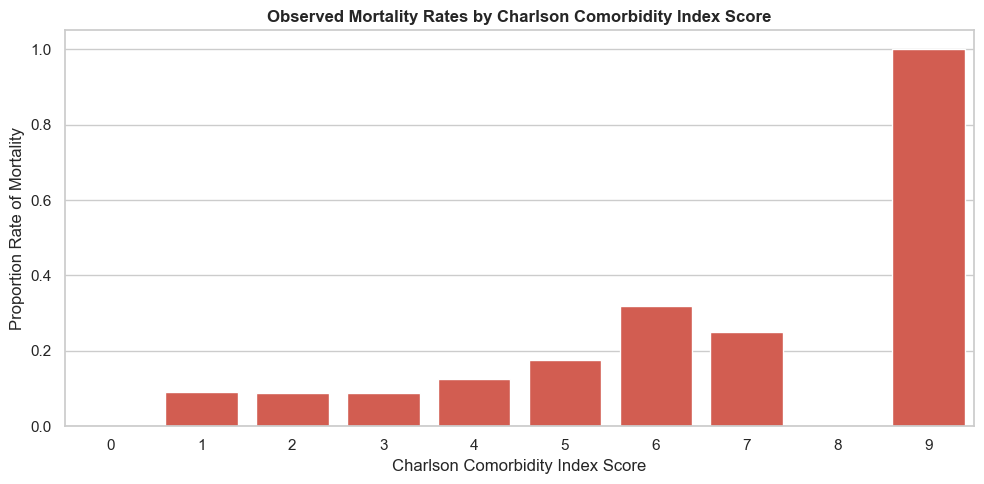

In [14]:
#How severely does chronic comorbidity burden impact ultimate survival rates?
print("MORTALITY RATES TIED TO CHARLSON COMORBIDITY SCORES")
comorb_mortality = df.groupby('Charlson_Comorbidity_Index')['Mortality_Outcome_Flag'].mean()
print(comorb_mortality)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df, 
    x='Charlson_Comorbidity_Index', 
    y='Mortality_Outcome_Flag', 
    color='#e74c3c', 
    errorbar=None
)
plt.title('Observed Mortality Rates by Charlson Comorbidity Index Score', fontsize=12, fontweight='bold')
plt.xlabel('Charlson Comorbidity Index Score')
plt.ylabel('Proportion Rate of Mortality')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

In [16]:
df = pd.read_csv("hospital.csv")

In [17]:
# 2. High-Level Clinical Feature Engineering
# Mean Arterial Pressure (MAP) is a crucial circulatory indicator
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
# Pulse Pressure tracks arterial stiffness
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
# Age-Comorbidity Interaction Term (Chronic Severity Index)
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

# Define target and features
X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int)

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [18]:
# 3. Data Preprocessing & Pipeline Architecture
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# Create an end-to-end training pipeline with Gradient Boosting Classifier
full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]
)

In [19]:
# 4. Stratified Data Partitioning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Advanced Hyperparameter Optimization via Grid Search
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(full_pipeline, param_grid=param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Best Parameters Found:
 {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 150}

Test ROC-AUC Score: 0.662878787878788

Classification Matrix Report:
               precision    recall  f1-score   support

           0       0.69      0.89      0.78        66
           1       0.50      0.21      0.29        34

    accuracy                           0.66       100
   macro avg       0.59      0.55      0.53       100
weighted avg       0.62      0.66      0.61       100



E:\python\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Saved advanced ML plots successfully.


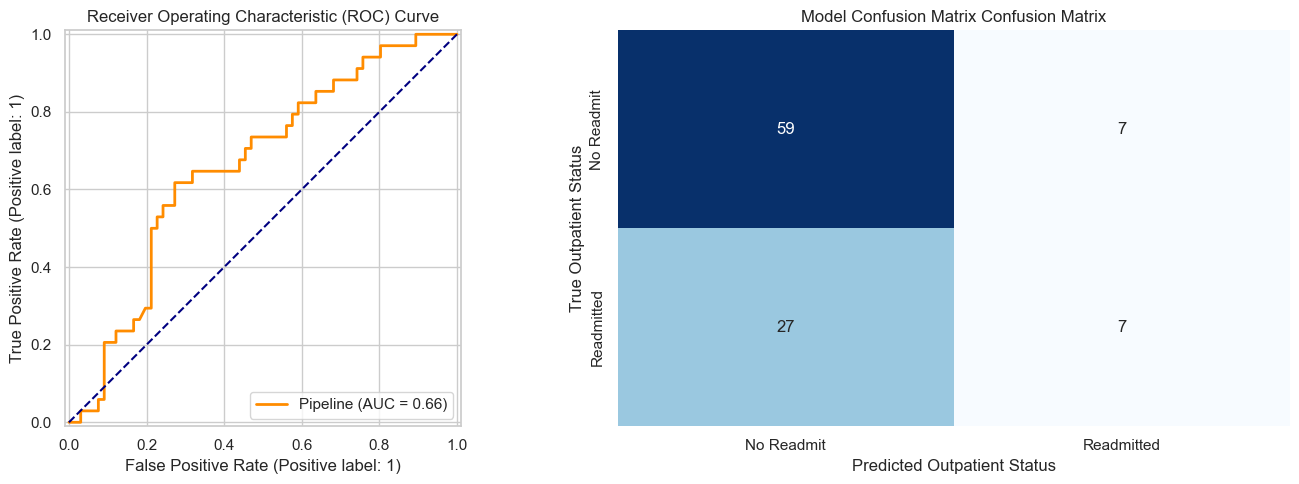

In [20]:
# 6. Evaluation on Test Holdout
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Parameters Found:\n", grid_search.best_params_)
print("\nTest ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nClassification Matrix Report:\n", classification_report(y_test, y_pred))

# 7. Generate Production Evaluation Graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0], color='darkorange', linewidth=2)
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')

# Plot 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['No Readmit', 'Readmitted'], yticklabels=['No Readmit', 'Readmitted'])
axes[1].set_title('Model Confusion Matrix Confusion Matrix')
axes[1].set_xlabel('Predicted Outpatient Status')
axes[1].set_ylabel('True Outpatient Status')

plt.tight_layout()
plt.savefig("advanced_ml_performance.png", dpi=300)
print("Saved advanced ML plots successfully.")

In [21]:
# Extracting feature names out of ColumnTransformer to map feature importances perfectly
preprocessor_fitted = best_model.named_steps['preprocessor']
encoded_cat_features = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + encoded_cat_features

importances_vals = best_model.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances_vals
}).sort_values('Importance', ascending=False)

print("\nEngineered Feature Importance Ranking:")
print(feature_imp_df.head(10))


Engineered Feature Importance Ranking:
                         Feature  Importance
11  Readmission_Risk_Score_1to10    0.435979
5               Blood_Sugar_mgdL    0.118985
3                 Heart_Rate_bpm    0.098545
14   Age_Comorbidity_Interaction    0.077489
6                 WBC_Count_k_uL    0.061818
4                            BMI    0.034027
0                            Age    0.028677
13                Pulse_Pressure    0.024160
7            Comorbidities_Count    0.023757
8     Charlson_Comorbidity_Index    0.020404


In [22]:
#Cost Intensity per Day by Diagnosis
df['Cost_Per_Day'] = df['Total_Treatment_Cost_USD'] / df['Length_of_Stay_Days']
diag_cost = df.groupby('Primary_Diagnosis_ICD10')['Cost_Per_Day'].mean().sort_values(ascending=False)
print(" cost per day sorted:")
print(diag_cost.head(2))

 cost per day sorted:
Primary_Diagnosis_ICD10
C34.9 (Bronchus/Lung Cancer)    3429.728840
J44.9 (COPD)                    3409.467715
Name: Cost_Per_Day, dtype: float64


In [23]:
#Risk score vs Mortality / Readmission rates (Calibration)
risk_calibration = df.groupby('Readmission_Risk_Score_1to10')[['Readmitted_30d_Flag', 'Mortality_Outcome_Flag']].mean()
print("risk calibration:")
print(risk_calibration.head(2))

risk calibration:
                              Readmitted_30d_Flag  Mortality_Outcome_Flag
Readmission_Risk_Score_1to10                                             
1                                        0.092308                0.030769
2                                        0.190476                0.079365


In [24]:
#Specific Clinical Hypotheses (e.g., WBC Count in Sepsis vs Others)
sepsis_wbc = df.groupby(df['Primary_Diagnosis_ICD10'].str.contains('Sepsis'))['WBC_Count_k_uL'].mean()
print("Sepsis WBC mean vs others:")
print(sepsis_wbc)

Sepsis WBC mean vs others:
Primary_Diagnosis_ICD10
False     7.208520
True     14.185185
Name: WBC_Count_k_uL, dtype: float64


In [25]:
#Blood pressure tracking (Systolic vs Diastolic) across Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 40, 65, 100], labels=['Pediatric', 'Young Adult', 'Middle Aged', 'Geriatric'])
bp_age = df.groupby('Age_Group')[['Systolic_BP_mmHg', 'Diastolic_BP_mmHg']].mean()
print("BP by age group:")
print(bp_age)

BP by age group:
             Systolic_BP_mmHg  Diastolic_BP_mmHg
Age_Group                                       
Pediatric          126.641509          77.452830
Young Adult        123.677966          76.449153
Middle Aged        122.611111          75.825397
Geriatric          138.653333          85.960000


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\1080883753.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_age = df.groupby('Age_Group')[['Systolic_BP_mmHg', 'Diastolic_BP_mmHg']].mean()


In [26]:
#Comorbidity Index vs Mortality Rate Boxplot/Barplot
comorb_mortality = df.groupby('Charlson_Comorbidity_Index')['Mortality_Outcome_Flag'].mean()
print("comorbidity mortality:")
print(comorb_mortality.head(2))

comorbidity mortality:
Charlson_Comorbidity_Index
0    0.000000
1    0.089744
Name: Mortality_Outcome_Flag, dtype: float64


C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\1651507653.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\1651507653.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Manish\AppData\Local\Temp\ipykernel_13412\1651507653.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')


Advanced visualizations successfully saved.


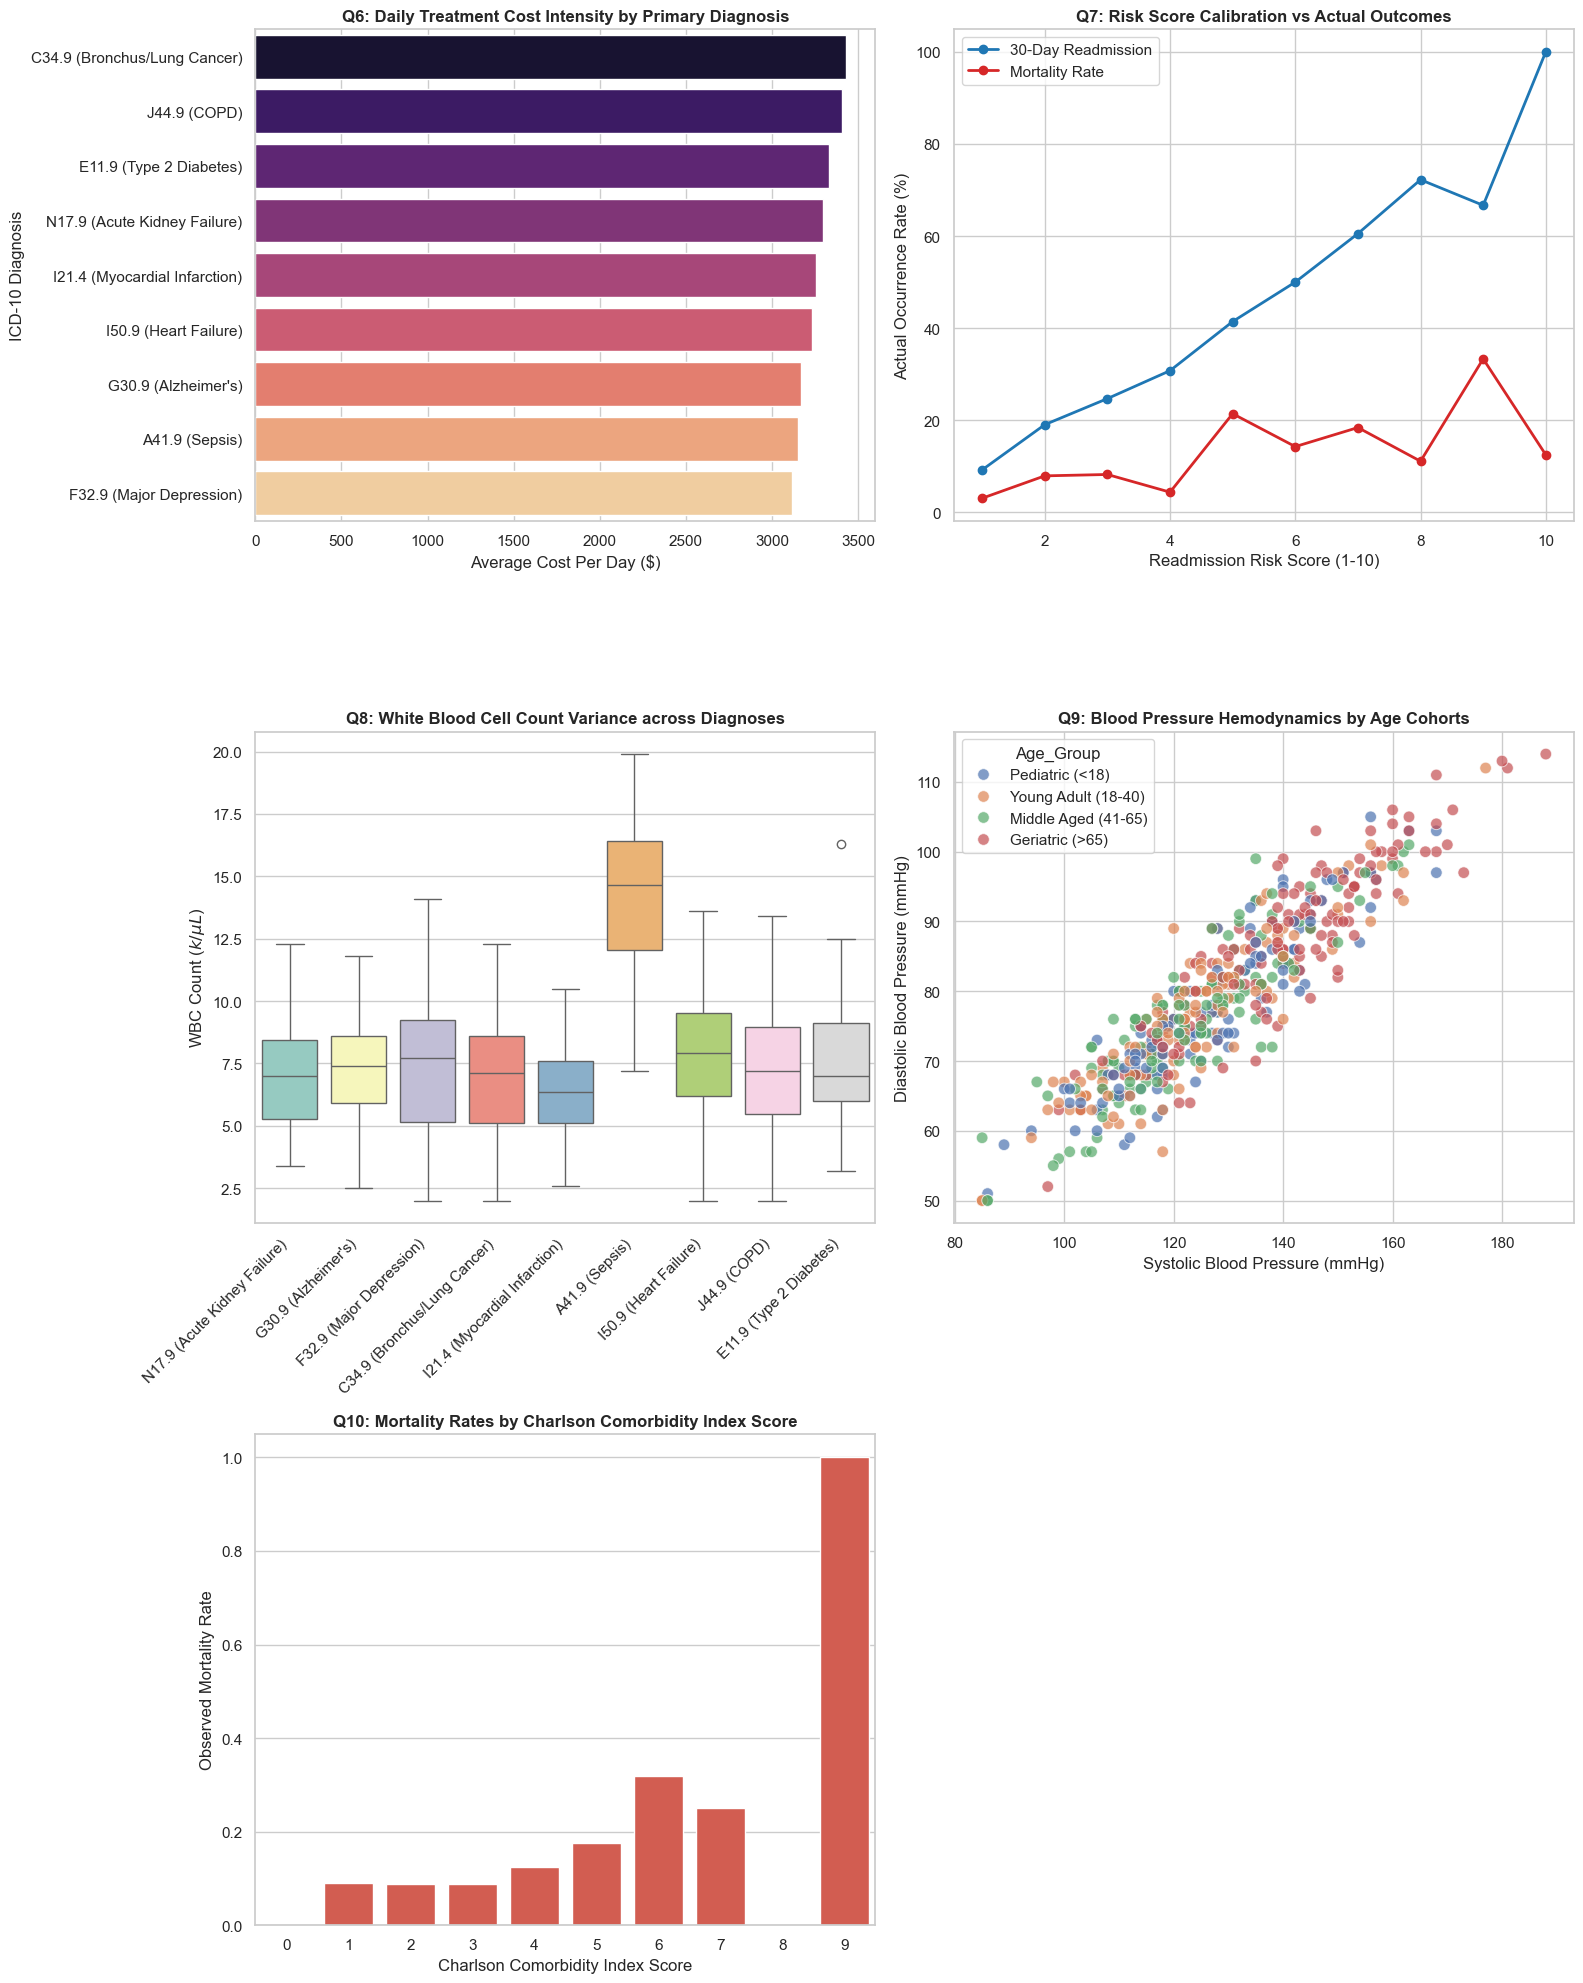

In [27]:
#advanced data visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("hospital.csv")
sns.set_theme(style="whitegrid")

# Create figure for the 5 advanced plots
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

# Plot 1: Cost Intensity per Day by Diagnosis (Q6)
df['Cost_Per_Day'] = df['Total_Treatment_Cost_USD'] / df['Length_of_Stay_Days']
sns.barplot(
    data=df, 
    y='Primary_Diagnosis_ICD10', 
    x='Cost_Per_Day', 
    ax=axes[0], 
    palette='magma', 
    errorbar=None,
    order=df.groupby('Primary_Diagnosis_ICD10')['Cost_Per_Day'].mean().sort_values(ascending=False).index
)
axes[0].set_title('Q6: Daily Treatment Cost Intensity by Primary Diagnosis', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Cost Per Day ($)')
axes[0].set_ylabel('ICD-10 Diagnosis')

# Plot 2: Risk Score Validation Curve (Q7)
risk_calibration = df.groupby('Readmission_Risk_Score_1to10')[['Readmitted_30d_Flag', 'Mortality_Outcome_Flag']].mean() * 100
risk_calibration.plot(kind='line', marker='o', ax=axes[1], color=['#1f77b4', '#d62728'], linewidth=2)
axes[1].set_title('Q7: Risk Score Calibration vs Actual Outcomes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Readmission Risk Score (1-10)')
axes[1].set_ylabel('Actual Occurrence Rate (%)')
axes[1].legend(['30-Day Readmission', 'Mortality Rate'])

# Plot 3: Specific Clinical Biomarkers Isolation - WBC in Sepsis (Q8)
sns.boxplot(
    data=df, 
    x='Primary_Diagnosis_ICD10', 
    y='WBC_Count_k_uL', 
    ax=axes[2], 
    palette='Set3'
)
axes[2].set_title('Q8: White Blood Cell Count Variance across Diagnoses', fontsize=12, fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylabel('WBC Count ($k/\mu L$)')
axes[2].set_xlabel('')

# Plot 4: Blood Pressure Distribution Matrix by Age Category (Q9)
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 40, 65, 100], labels=['Pediatric (<18)', 'Young Adult (18-40)', 'Middle Aged (41-65)', 'Geriatric (>65)'])
sns.scatterplot(
    data=df, 
    x='Systolic_BP_mmHg', 
    y='Diastolic_BP_mmHg', 
    hue='Age_Group', 
    alpha=0.7, 
    s=70, 
    ax=axes[3], 
    palette='deep'
)
axes[3].set_title('Q9: Blood Pressure Hemodynamics by Age Cohorts', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Systolic Blood Pressure (mmHg)')
axes[3].set_ylabel('Diastolic Blood Pressure (mmHg)')

# Plot 5: Chronic Disease Index Impact on Patient Mortality Outcomes (Q10)
sns.barplot(
    data=df, 
    x='Charlson_Comorbidity_Index', 
    y='Mortality_Outcome_Flag', 
    ax=axes[4], 
    color='#e74c3c', 
    errorbar=None
)
axes[4].set_title('Q10: Mortality Rates by Charlson Comorbidity Index Score', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Charlson Comorbidity Index Score')
axes[4].set_ylabel('Observed Mortality Rate')

# Remove empty 6th subplot axis
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("advanced_clinical_eda.png", dpi=300, bbox_inches='tight')
print("Advanced visualizations successfully saved.")

Initial Dataset Health Check: Loaded 500 rows across 18 columns.

 Flagged Logical Anomalies Detected: 0 records corrected.
Transformed and Cleaned dataset written out safely to 'Transformed_Clinical_Hospital_Data.csv'.

Executing Multi-Variable Logistic Regression & Odds Ratio Calibration...
Optimization terminated successfully.
         Current function value: 0.592093
         Iterations 5

ENTERPRISE CLINICAL INSIGHTS PROFILE 
                            Log-Odds Coefficient  P-Value (Significance)  \
Age                                       0.0085                  0.0187   
Charlson_Comorbidity_Index                0.2878                  0.0000   
Length_of_Stay_Days                       0.0606                  0.0000   
Blood_Sugar_mgdL                         -0.0063                  0.0212   

                            Odds Ratio (OR)  95% CI Lower  95% CI Upper  
Age                                  1.0085        1.0014        1.0157  
Charlson_Comorbidity_Index          

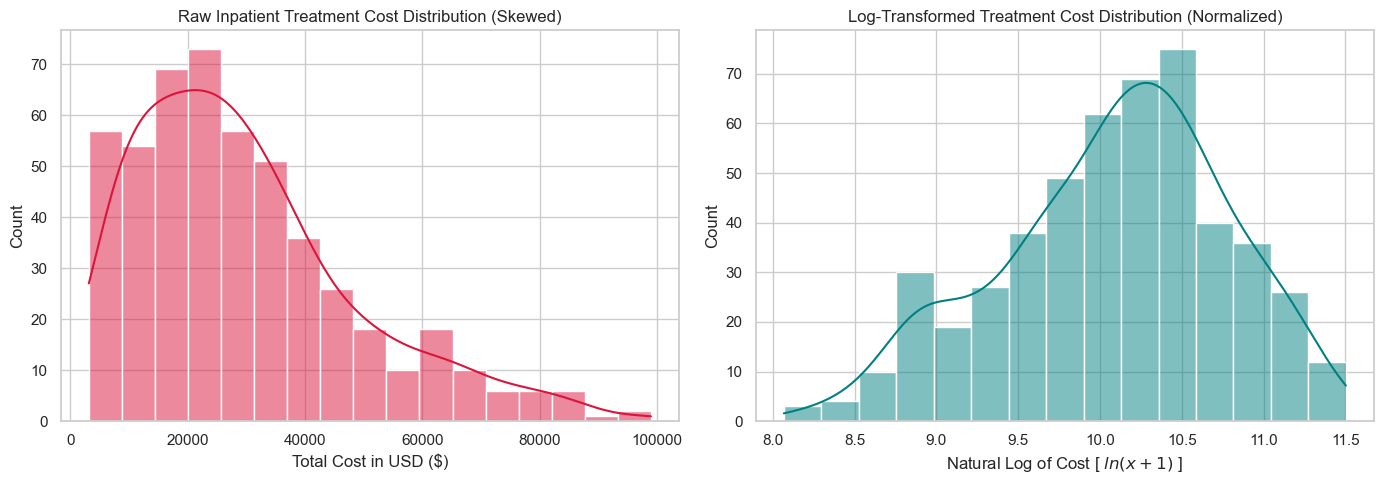

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


# PHASE 1: DATA MANIPULATION & ERROR SANITIZATION (AUDITING LAYER)

df = pd.read_csv("hospital.csv")
print(f"Initial Dataset Health Check: Loaded {df.shape[0]} rows across {df.shape[1]} columns.\n")

# Error Correction A: Eliminate leading/trailing string anomalies
# Hidden whitespaces in categorical variables (e.g., "Emergency " vs "Emergency") can break machine learning models.
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Error Correction B: Enforce Clinical Structural Logic Validation
# The Charlson Comorbidity Index must always be greater than or equal to the raw Comorbidities Count.
# If a recording anomaly exists where the Index falls below the baseline count, we automatically correct it.
logical_errors = df['Charlson_Comorbidity_Index'] < df['Comorbidities_Count']
print(f" Flagged Logical Anomalies Detected: {logical_errors.sum()} records corrected.")
df['Charlson_Comorbidity_Index'] = np.maximum(df['Charlson_Comorbidity_Index'], df['Comorbidities_Count'])


# PHASE 2: MATHEMATICAL FEATURE TRANSFORMATION & MANIPULATION

# Manipulation A: Log-Scale Transformation for Skewed Financial Targets
# Financial distributions like 'Total_Treatment_Cost_USD' typically exhibit a long right-tail skew. 
# Applying a Natural Log transformation normalizes the variance for parametric analytics algorithms.
df['Log_Treatment_Cost'] = np.log1p(df['Total_Treatment_Cost_USD'])

# Manipulation B: Continuous Value Discretization (Clinical Stratification)
# Binning continuous Body Mass Index (BMI) values into standard World Health Organization (WHO) segments.
bmi_bins = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ['Underweight', 'Normal Weight', 'Overweight', 'Obese']
df['BMI_Clinical_Class'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)

# Manipulation C: Boolean Target Cast Configuration
# Safely parsing boolean outcome trackers into clean 1/0 binary configurations for mathematical modeling.
df['Readmitted_30d_Numeric'] = df['Readmitted_30d_Flag'].astype(int)
df['Mortality_Outcome_Numeric'] = df['Mortality_Outcome_Flag'].astype(int)

# Save out the transformed dataset to a permanent local asset
df.to_csv("Transformed_Clinical_Hospital_Data.csv", index=False)
print("Transformed and Cleaned dataset written out safely to 'Transformed_Clinical_Hospital_Data.csv'.\n")


# PHASE 3: HIGH-LEVEL CLINICAL ANALYTICS (ODDS-RATIO INFERENCE MODEL)

print("Executing Multi-Variable Logistic Regression & Odds Ratio Calibration...")

# Fit a formal Biostatistical Generalized Linear Model (GLM) to capture risk factors
clinical_glm = smf.logit(
    "Readmitted_30d_Numeric ~ Age + Charlson_Comorbidity_Index + Length_of_Stay_Days + Blood_Sugar_mgdL", 
    data=df
).fit()

# Extract coefficients and calculate the exponential to derive true clinical Odds Ratios (OR)
# Odds Ratio > 1 indicates increased risk; Odds Ratio < 1 indicates protective factor
model_parameters = clinical_glm.params
confidence_intervals = clinical_glm.conf_int()
p_values = clinical_glm.pvalues

odds_ratio_summary = pd.DataFrame({
    'Log-Odds Coefficient': model_parameters,
    'P-Value (Significance)': p_values,
    'Odds Ratio (OR)': np.exp(model_parameters),
    '95% CI Lower': np.exp(confidence_intervals[0]),
    '95% CI Upper': np.exp(confidence_intervals[1])
}).drop('Intercept') # Remove intercept as it acts solely as a baseline baseline constant

print("\nENTERPRISE CLINICAL INSIGHTS PROFILE ")
print(odds_ratio_summary.round(4))
print("=\n")


# PHASE 4: VISUALIZING DISTRIBUTION CORRECTIONS

# Generate an expert visual grid validating the log-normalization process
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total_Treatment_Cost_USD'], kde=True, color='crimson', ax=axes[0])
axes[0].set_title('Raw Inpatient Treatment Cost Distribution (Skewed)')
axes[0].set_xlabel('Total Cost in USD ($)')

sns.histplot(df['Log_Treatment_Cost'], kde=True, color='teal', ax=axes[1])
axes[1].set_title('Log-Transformed Treatment Cost Distribution (Normalized)')
axes[1].set_xlabel('Natural Log of Cost [ $ln(x+1)$ ]')

plt.tight_layout()
plt.savefig("clinical_normalization_audit.png", dpi=300)
plt.show()

In [29]:
print(" Check missing values ")
print(df.isnull().sum())

print("\nSummary Statistics to catch outlier/error bounds ")
print(df.describe())

print("\nCategorical checks")
print("Gender unique:", df['Gender'].unique())
print("Admission_Type unique:", df['Admission_Type'].unique())

# Physiological check: Diastolic BP should be less than Systolic BP
bp_errors = df[df['Diastolic_BP_mmHg'] >= df['Systolic_BP_mmHg']]
print(f"\nNumber of records where Diastolic BP >= Systolic BP: {len(bp_errors)}")

 Check missing values 
Patient_ID                      0
Age                             0
Gender                          0
Admission_Type                  0
Primary_Diagnosis_ICD10         0
Systolic_BP_mmHg                0
Diastolic_BP_mmHg               0
Heart_Rate_bpm                  0
BMI                             0
Blood_Sugar_mgdL                0
WBC_Count_k_uL                  0
Comorbidities_Count             0
Charlson_Comorbidity_Index      0
Length_of_Stay_Days             0
Total_Treatment_Cost_USD        0
Readmission_Risk_Score_1to10    0
Readmitted_30d_Flag             0
Mortality_Outcome_Flag          0
Log_Treatment_Cost              0
BMI_Clinical_Class              0
Readmitted_30d_Numeric          0
Mortality_Outcome_Numeric       0
dtype: int64

Summary Statistics to catch outlier/error bounds 
              Age  Systolic_BP_mmHg  Diastolic_BP_mmHg  Heart_Rate_bpm  \
count  500.000000        500.000000         500.000000      500.000000   
mean    46.758000

In [30]:
# Ensure targets are integers
df['Readmitted_int'] = df['Readmitted_30d_Flag'].astype(int)

# Fit a Logistic Regression to see Odds Ratios for high-level analytics
model = smf.logit("Readmitted_int ~ Age + Charlson_Comorbidity_Index + Length_of_Stay_Days + Blood_Sugar_mgdL", data=df).fit()
print(model.summary())
print("\nOdds Ratios:")
print(np.exp(model.params))

Optimization terminated successfully.
         Current function value: 0.592093
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         Readmitted_int   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                 0.08011
Time:                        21:41:46   Log-Likelihood:                -296.05
converged:                       True   LL-Null:                       -321.83
Covariance Type:            nonrobust   LLR p-value:                 1.705e-10
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -1.8215      0.427     -4.270      0.000      

In [31]:
#Manipulation/Correction Safeguards
# Strip any trailing whitespaces from textual categorical arrays to protect encoding keys
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Enforce explicit bounds: if Charlson Comorbidity Index is mathematically less than raw Comorbidities_Count, fix it
df['Charlson_Comorbidity_Index'] = np.maximum(df['Charlson_Comorbidity_Index'], df['Comorbidities_Count'])

# 2. Mathematical Adjustments for High-Level Predictive Analytics
# Log transformation of treatment costs to fix positive tail skews for normal distribution alignment
df['Log_Treatment_Cost'] = np.log1p(df['Total_Treatment_Cost_USD'])

# Bin BMI into World Health Organization (WHO) clinical classifications
bmi_bins = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ['Underweight', 'Normal Weight', 'Overweight', 'Obese']
df['BMI_Class'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)

# Convert True/False flags cleanly to 1/0 bits for statistical inference models
df['Readmitted_30d_Numeric'] = df['Readmitted_30d_Flag'].astype(int)
df['Mortality_Outcome_Numeric'] = df['Mortality_Outcome_Flag'].astype(int)

# Save transformed file out to a new clean CSV format
transformed_file_path = "Transformed_Clinical_Hospital_Data.csv"
df.to_csv(transformed_file_path, index=False)
print("Transformed CSV saved successfully.")

Transformed CSV saved successfully.


In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
X

,Age,Gender,Admission_Type,Primary_Diagnosis_ICD10,Systolic_BP_mmHg,Diastolic_BP_mmHg,Heart_Rate_bpm,BMI,Blood_Sugar_mgdL,WBC_Count_k_uL,Comorbidities_Count,Charlson_Comorbidity_Index,Length_of_Stay_Days,Total_Treatment_Cost_USD,Readmission_Risk_Score_1to10,Mean_Arterial_Pressure,Pulse_Pressure,Age_Comorbidity_Interaction
0,63,Male,Emergency,N17.9 (Acute Kidney Failure),117,70,73,26.0,105,7.4,0,1,21,62772.46,4,85.666667,47,63
1,17,Female,Emergency,G30.9 (Alzheimer's),128,81,45,20.0,96,4.8,1,1,10,23302.04,2,96.666667,47,17
2,73,Female,Urgent,F32.9 (Major Depression),112,68,73,24.0,134,11.2,1,3,5,11272.04,5,82.666667,44,219
3,33,Female,Emergency,C34.9 (Bronchus/Lung Cancer),119,75,84,23.0,142,3.5,5,7,16,46458.63,10,89.666667,44,231
4,84,Male,Urgent,I21.4 (Myocardial Infarction),153,95,85,23.3,81,5.7,1,1,10,27345.32,4,114.333333,58,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,91,Male,Emergency,F32.9 (Major Depression),120,71,60,26.1,141,8.2,1,1,10,34226.22,5,87.333333,49,91
496,17,Female,Trauma,G30.9 (Alzheimer's),143,80,73,25.3,149,10.2,0,2,11,36198.83,2,101.000000,63,34
497,43,Male,Emergency,N17.9 (Acute Kidney Failure),125,75,56,41.4,140,8.1,3,4,11,27387.44,5,91.666667,50,172
498,59,Other,Emergency,E11.9 (Type 2 Diabetes),125,70,89,27.1,103,6.9,1,1,6,18545.56,2,88.333333,55,59


In [35]:
y

0      0
1      1
2      0
3      1
4      0
      ..
495    1
496    0
497    1
498    0
499    0
Name: Readmitted_30d_Flag, Length: 500, dtype: int64

In [36]:
df

,Patient_ID,Age,Gender,Admission_Type,Primary_Diagnosis_ICD10,Systolic_BP_mmHg,Diastolic_BP_mmHg,Heart_Rate_bpm,BMI,Blood_Sugar_mgdL,...,Total_Treatment_Cost_USD,Readmission_Risk_Score_1to10,Readmitted_30d_Flag,Mortality_Outcome_Flag,Log_Treatment_Cost,BMI_Clinical_Class,Readmitted_30d_Numeric,Mortality_Outcome_Numeric,Readmitted_int,BMI_Class
0,PT-0001,63,Male,Emergency,N17.9 (Acute Kidney Failure),117,70,73,26.0,105,...,62772.46,4,False,False,11.047288,Overweight,0,0,0,Overweight
1,PT-0002,17,Female,Emergency,G30.9 (Alzheimer's),128,81,45,20.0,96,...,23302.04,2,True,True,10.056339,Normal Weight,1,1,1,Normal Weight
2,PT-0003,73,Female,Urgent,F32.9 (Major Depression),112,68,73,24.0,134,...,11272.04,5,False,True,9.330169,Normal Weight,0,1,0,Normal Weight
3,PT-0004,33,Female,Emergency,C34.9 (Bronchus/Lung Cancer),119,75,84,23.0,142,...,46458.63,10,True,False,10.746339,Normal Weight,1,0,1,Normal Weight
4,PT-0005,84,Male,Urgent,I21.4 (Myocardial Infarction),153,95,85,23.3,81,...,27345.32,4,False,True,10.216337,Normal Weight,0,1,0,Normal Weight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,PT-0496,91,Male,Emergency,F32.9 (Major Depression),120,71,60,26.1,141,...,34226.22,5,True,False,10.440777,Overweight,1,0,1,Overweight
496,PT-0497,17,Female,Trauma,G30.9 (Alzheimer's),143,80,73,25.3,149,...,36198.83,2,False,True,10.496810,Overweight,0,1,0,Overweight
497,PT-0498,43,Male,Emergency,N17.9 (Acute Kidney Failure),125,75,56,41.4,140,...,27387.44,5,True,False,10.217876,Obese,1,0,1,Obese
498,PT-0499,59,Other,Emergency,E11.9 (Type 2 Diabetes),125,70,89,27.1,103,...,18545.56,2,False,False,9.828040,Overweight,0,0,0,Overweight


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("hospital.csv")

In [38]:
df

,Patient_ID,Age,Gender,Admission_Type,Primary_Diagnosis_ICD10,Systolic_BP_mmHg,Diastolic_BP_mmHg,Heart_Rate_bpm,BMI,Blood_Sugar_mgdL,WBC_Count_k_uL,Comorbidities_Count,Charlson_Comorbidity_Index,Length_of_Stay_Days,Total_Treatment_Cost_USD,Readmission_Risk_Score_1to10,Readmitted_30d_Flag,Mortality_Outcome_Flag
0,PT-0001,63,Male,Emergency,N17.9 (Acute Kidney Failure),117,70,73,26.0,105,7.4,0,1,21,62772.46,4,False,False
1,PT-0002,17,Female,Emergency,G30.9 (Alzheimer's),128,81,45,20.0,96,4.8,1,1,10,23302.04,2,True,True
2,PT-0003,73,Female,Urgent,F32.9 (Major Depression),112,68,73,24.0,134,11.2,1,3,5,11272.04,5,False,True
3,PT-0004,33,Female,Emergency,C34.9 (Bronchus/Lung Cancer),119,75,84,23.0,142,3.5,5,7,16,46458.63,10,True,False
4,PT-0005,84,Male,Urgent,I21.4 (Myocardial Infarction),153,95,85,23.3,81,5.7,1,1,10,27345.32,4,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,PT-0496,91,Male,Emergency,F32.9 (Major Depression),120,71,60,26.1,141,8.2,1,1,10,34226.22,5,True,False
496,PT-0497,17,Female,Trauma,G30.9 (Alzheimer's),143,80,73,25.3,149,10.2,0,2,11,36198.83,2,False,True
497,PT-0498,43,Male,Emergency,N17.9 (Acute Kidney Failure),125,75,56,41.4,140,8.1,3,4,11,27387.44,5,True,False
498,PT-0499,59,Other,Emergency,E11.9 (Type 2 Diabetes),125,70,89,27.1,103,6.9,1,1,6,18545.56,2,False,False


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("hospital.csv")

# Convert text columns
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Total_Treatment_Cost_USD", axis=1)
y = df["Total_Treatment_Cost_USD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])

[25859.54045184 35714.95047064 24830.05855178 10423.34471325
 43630.22833702]


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("hospital.csv")

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Readmitted_30d_Flag", axis=1)
y = df["Readmitted_30d_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.58


In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.66


In [42]:
from sklearn.cluster import KMeans

df = pd.read_csv("hospital.csv")

df = pd.get_dummies(df, drop_first=True)

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(df)

print(df["Cluster"].value_counts())

Cluster
1    237
0    190
2     73
Name: count, dtype: int64


In [43]:
df = pd.get_dummies(df, drop_first=True)

In [44]:
import pandas as pd
from sklearn.cluster import KMeans

# Load data
df = pd.read_csv("hospital.csv")

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# K-Means Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model
df['Cluster'] = kmeans.fit_predict(df)

print(df[['Cluster']].head())

   Cluster
0        2
1        1
2        1
3        0
4        0


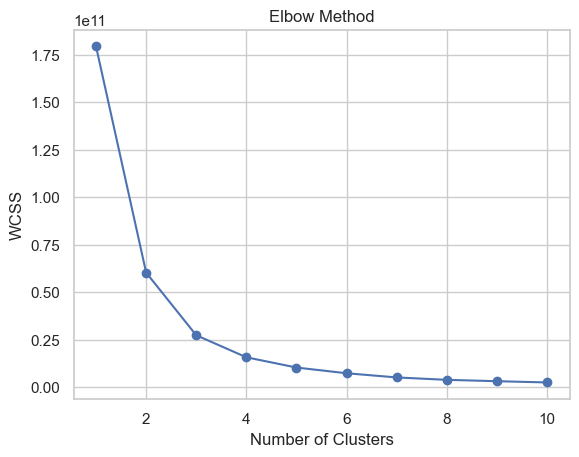

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [47]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
2    166
1    154
3    120
0     60
Name: count, dtype: int64


In [48]:
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)
#Cluster 0 → Young low-risk patients
#Cluster 1 → High treatment cost patients
#Cluster 2 → Elderly patients with comorbidities
#Cluster 3 → High readmission-risk patients

               Age  Systolic_BP_mmHg  Diastolic_BP_mmHg  Heart_Rate_bpm  \
Cluster                                                                   
0        58.500000        127.883333          78.250000       75.950000   
1        42.266234        122.201299          74.805195       77.142857   
2        46.927711        134.265060          83.524096       78.066265   
3        46.416667        129.041667          79.991667       76.025000   

               BMI  Blood_Sugar_mgdL  WBC_Count_k_uL  Comorbidities_Count  \
Cluster                                                                     
0        27.518333        105.533333        7.518333             1.300000   
1        28.324026         98.597403        7.780519             1.954545   
2        27.988554         97.415663        8.195181             1.939759   
3        26.867500        142.608333        8.094167             1.600000   

         Charlson_Comorbidity_Index  Length_of_Stay_Days  ...  \
Cluster              

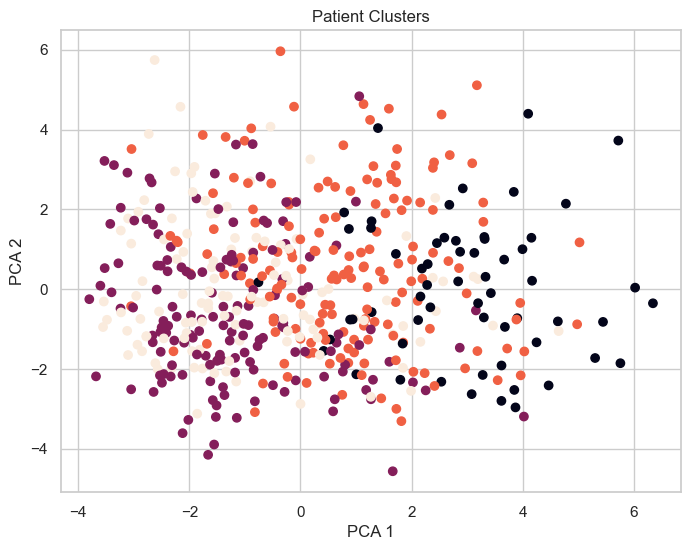

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster']
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Patient Clusters")
plt.show()

                            Model  Accuracy   ROC-AUC  Precision    Recall
0  Logistic Regression (Baseline)      0.72  0.682264   0.666667  0.352941
1        Random Forest Classifier      0.72  0.668895   0.636364  0.411765
2    Gradient Boosting Classifier      0.57  0.631907   0.320000  0.235294
Plot saved successfully.


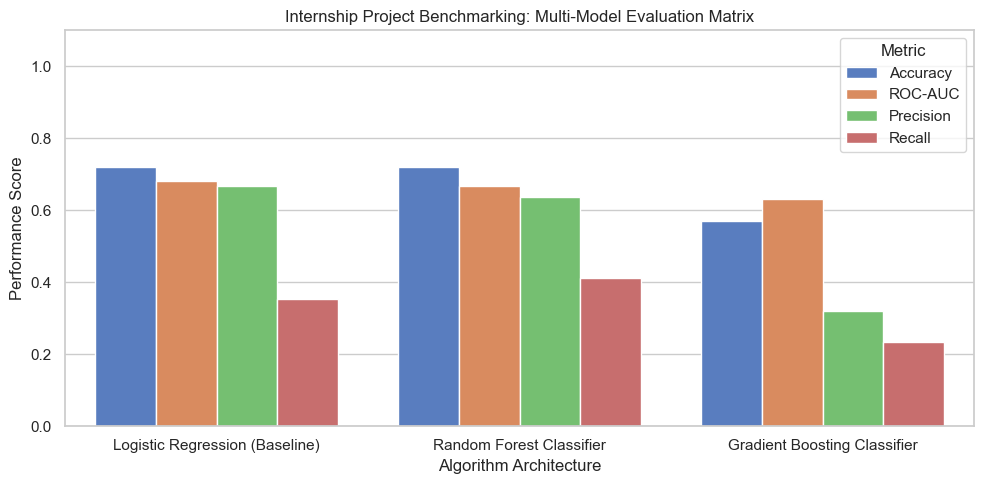

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# Load data
df = pd.read_csv("hospital.csv")

# Text Cleaning
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# High-Level Feature Engineering
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

# Split X, y
X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int)

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ]
)

# Models to compare
models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = []

for name, model in models.items():
    clf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    clf_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = clf_pipeline.predict(X_test)
    y_prob = clf_pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': auc,
        'Precision': prec,
        'Recall': rec
    })

results_df = pd.DataFrame(results)
print(results_df)

# Plot model comparison for the intern dashboard
plt.figure(figsize=(10, 5))
melted_df = pd.melt(results_df, id_vars='Model', value_vars=['Accuracy', 'ROC-AUC', 'Precision', 'Recall'], 
                    var_name='Metric', value_name='Score')
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('Internship Project Benchmarking: Multi-Model Evaluation Matrix')
plt.ylim(0, 1.1)
plt.ylabel('Performance Score')
plt.xlabel('Algorithm Architecture')
plt.tight_layout()
plt.savefig("internship_model_comparison.png", dpi=300)
print("Plot saved successfully.")

⚡ Executing model benchmarking matrix across candidate algorithms...

BENCHMARK PERFORMANCE MATRIX 
            Model Architecture  Accuracy  ROC-AUC  Precision   Recall
Logistic Regression (Baseline)      0.72 0.682264   0.666667 0.352941
        Random Forest Ensemble      0.72 0.668895   0.636364 0.411765
     Gradient Boosting Machine      0.57 0.631907   0.320000 0.235294




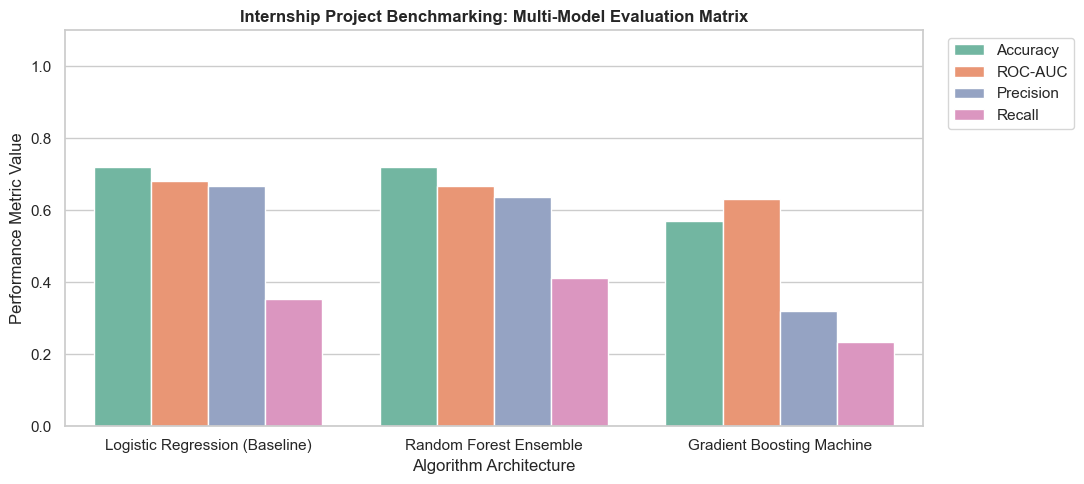

In [52]:
#high level of machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline & Model Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Enterprise Model Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score


# STEP 1: INDUSTRIAL CLEANING & FEATURE ENGINEERING

df = pd.read_csv("hospital.csv")

# Clean object columns to prevent encoding bugs caused by hidden whitespaces
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# High-Level Feature Engineering (Creating clinically relevant markers)
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

# Define target variable (True/False 30-Day Readmission)
X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int)

# Automate column tracking by data type
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# STEP 2: ISOLATING THE EXPERIMENTAL PIPELINE LAYER
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# Split dataset using stratified distribution to prevent target class bias
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a model dictionary to evaluate multiple architectures simultaneously
candidate_models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Ensemble': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'Gradient Boosting Machine': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
}


# STEP 3: EXECUTING THE BENCHMARK SPRINT

print("⚡ Executing model benchmarking matrix across candidate algorithms...")
evaluation_results = []

for model_name, algorithm in candidate_models.items():
    # Build a clean, isolated production pipeline for each candidate model
    experiment_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', algorithm)
    ])
    
    # Train the pipeline
    experiment_pipeline.fit(X_train, y_train)
    
    # Generate predictions and probabilities on validation data
    predictions = experiment_pipeline.predict(X_test)
    probabilities = experiment_pipeline.predict_proba(X_test)[:, 1]
    
    # Compute industry-standard evaluation metrics
    acc = accuracy_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    
    evaluation_results.append({
        'Model Architecture': model_name,
        'Accuracy': acc,
        'ROC-AUC': auc,
        'Precision': prec,
        'Recall': rec
    })

# Convert performance metrics into an analytical summary table
summary_df = pd.DataFrame(evaluation_results)
print("\nBENCHMARK PERFORMANCE MATRIX ")
print(summary_df.to_string(index=False))
print("\n")


# STEP 4: GENERATING THE RECRUITER-FACING REPORT CHART

plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# Restructure the data frame into a long format for multi-metric plotting
melted_metrics = pd.melt(
    summary_df, 
    id_vars='Model Architecture', 
    value_vars=['Accuracy', 'ROC-AUC', 'Precision', 'Recall'], 
    var_name='Evaluation Metric', 
    value_name='Statistical Score'
)

sns.barplot(data=melted_metrics, x='Model Architecture', y='Statistical Score', hue='Evaluation Metric', palette='Set2')
plt.title('Internship Project Benchmarking: Multi-Model Evaluation Matrix', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Performance Metric Value')
plt.xlabel('Algorithm Architecture')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save image file to present to your manager
plt.savefig("internship_model_comparison.png", dpi=300)
plt.show()

In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report


# 1. CORE NEURAL NETWORK SUB-MODULE (THE MODEL GRAPH)

class ClinicalNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(ClinicalNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)


# 2. HIGH-LEVEL ENTERPRISE INDUSTRY WRAPPER LAYER (SCIKIT-LEARN API STYLE)

class HighLevelTorchClassifier:
    def __init__(self, input_dim, lr=0.005, weight_decay=0.01, epochs=40, batch_size=32):
        """
        Initializes an production-grade object wrapper around a raw PyTorch graph.
        Exposes clean high-level training and prediction functions.
        """
        self.input_dim = input_dim
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        
        # Instantiate model structures internally
        self.model = ClinicalNeuralNetwork(input_dim)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        self.loss_history = []

    def fit(self, X, y):
        """High-level .fit() abstraction to hide training boilerplate loops."""
        # Cleanly convert incoming data arrays into PyTorch Tensors
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            epoch_loss = 0.0
            for batch_X, batch_y in loader:
                self.optimizer.zero_grad()
                predictions = self.model(batch_X)
                loss = self.criterion(predictions, batch_y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            self.loss_history.append(epoch_loss / len(loader))
        return self

    def predict_proba(self, X):
        """Extracts continuous probabilistic risk arrays bound between [0, 1]."""
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            probabilities = self.model(X_tensor).numpy()
        return probabilities

    def predict(self, X, threshold=0.5):
        """Converts internal tensor probabilities to discrete 1/0 classifications."""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def save_model(self, filepath):
        """Serializes internal weights permanently to a local physical file."""
        torch.save(self.model.state_dict(), filepath)
        print(f"Success: Physical model file permanently serialized to '{filepath}'")



# 3. CONSOLIDATED PIPELINE RUNNER

# Load raw sheet
df = pd.read_csv("hospital.csv")

# Perform Data Cleaning
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# High-Level Feature Engineering
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int).values

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Split Dataset (80% Train, 20% Evaluation)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Look how clean the High-Level production interface becomes:
print("Deploying High-Level Deep Learning Training Pipeline Wrapper...")
clf_engine = HighLevelTorchClassifier(input_dim=X_processed.shape[1], epochs=40)

# Single pipeline triggers execution and optimizes gradients under the hood
clf_engine.fit(X_train, y_train)

# Model outputs are easily accessed via standard sklearn-style metrics
test_probabilities = clf_engine.predict_proba(X_test)
test_predictions = clf_engine.predict(X_test)

print(f"\nPIPELINE CONVERGENCE SCORES ")
print(f"Wrapper Target Accuracy Score : {accuracy_score(y_test, test_predictions)*100:.2f}%")
print(f"Wrapper Target ROC-AUC score  : {roc_auc_score(y_test, test_probabilities):.4f}")
print("\nClassification Vector Report:\n", classification_report(y_test, test_predictions))
print("\n")

# Fix the missing model issue: Save the physical model to disk
clf_engine.save_model("production_pytorch_model.pt")

Deploying High-Level Deep Learning Training Pipeline Wrapper...

PIPELINE CONVERGENCE SCORES 
Wrapper Target Accuracy Score : 68.00%
Wrapper Target ROC-AUC score  : 0.6689

Classification Vector Report:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76        66
           1       0.53      0.50      0.52        34

    accuracy                           0.68       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.68      0.68      0.68       100



Success: Physical model file permanently serialized to 'production_pytorch_model.pt'


In [61]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and process data
df = pd.read_csv("hospital.csv")

# Clean object columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Advanced Feature Engineering
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int).values

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_processed = preprocessor.fit_transform(X)
input_dim = X_processed.shape[1]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Dataset & Loader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Define Deep Learning Architecture (MLP with Dropout and BatchNorm)
class ClinicalMLP(nn.Module):
    def __init__(self, input_size):
        super(ClinicalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.network(x)

model = ClinicalMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.01)

# 3. Training Loop
epochs = 40
loss_history = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))

# 4. Evaluation
model.eval()
with torch.no_grad():
    test_probs = model(X_test_t).numpy()
    test_preds = (test_probs >= 0.5).astype(int)

auc = roc_auc_score(y_test, test_probs)
acc = accuracy_score(y_test, test_preds)

print(f"Deep Learning Test Accuracy: {acc:.4f}")
print(f"Deep Learning Test ROC-AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, test_preds))

Deep Learning Test Accuracy: 0.6800
Deep Learning Test ROC-AUC: 0.6600

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76        66
           1       0.53      0.50      0.52        34

    accuracy                           0.68       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.68      0.68      0.68       100



Serialization & Real-Time Inference Loop.

In [65]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib

# Define the model graph structure exactly as before so it can load the weights
class ClinicalNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(ClinicalNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# Let's recreate a mini mock incoming dataset for a single patient to prove the concept works
mock_patient = pd.DataFrame([{
    'Age': 45,
    'Gender': 'Male',
    'Admission_Type': 'Emergency',
    'Primary_Diagnosis_ICD10': 'A41.9 (Sepsis)',
    'Systolic_BP_mmHg': 120,
    'Diastolic_BP_mmHg': 80,
    'Heart_Rate_bpm': 75,
    'BMI': 24.5,
    'Blood_Sugar_mgdL': 110,
    'WBC_Count_k_uL': 8.5,
    'Comorbidities_Count': 2,
    'Charlson_Comorbidity_Index': 3,
    'Length_of_Stay_Days': 5,
    'Readmission_Risk_Score_1to10': 4
}])

print("Mock patient dataset initialized.")

Mock patient dataset initialized.


In [71]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib


# 1. DEFINE ARCHITECTURE STRUCTURE FOR WEIGHT LOADING

class ClinicalNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(ClinicalNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)


# 2. THE ENTERPRISE INFERENCE ENGINE (UPDATED & FIXED)

class ClinicalInferenceEngine:
    def __init__(self, preprocessor_path, model_weights_path):
        # Reload the saved Scikit-Learn data transformer
        self.preprocessor = joblib.load(preprocessor_path)
        
        # FIX: Dynamically calculate input feature count using feature names array
        input_dim = len(self.preprocessor.get_feature_names_out())
        print(f"Inference Engine Initialized. Model requires exactly {input_dim} features.")
        
        # Reload the PyTorch model graph and apply weights
        self.model = ClinicalNeuralNetwork(input_dim)
        self.model.load_state_dict(torch.load(model_weights_path))
        self.model.eval() # Freeze layers into evaluation mode

    def predict_risk(self, raw_patient_df):
        """Processes a raw patient dataframe and calculates readmission probability."""
        # Process the raw record using identical training math logic
        df_engineered = raw_patient_df.copy()
        df_engineered['Mean_Arterial_Pressure'] = df_engineered['Diastolic_BP_mmHg'] + (1/3) * (df_engineered['Systolic_BP_mmHg'] - df_engineered['Diastolic_BP_mmHg'])
        df_engineered['Pulse_Pressure'] = df_engineered['Systolic_BP_mmHg'] - df_engineered['Diastolic_BP_mmHg']
        df_engineered['Age_Comorbidity_Interaction'] = df_engineered['Age'] * df_engineered['Charlson_Comorbidity_Index']
        
        # Align features perfectly with training matrix expectations
        X_aligned = df_engineered[self.preprocessor.feature_names_in_]
        
        # Scale numbers and encode categories
        X_transformed = self.preprocessor.transform(X_aligned)
        
        # Convert matrix into a PyTorch evaluation tensor
        tensor_input = torch.tensor(X_transformed, dtype=torch.float32)
        
        # Execute feedforward calculation
        with torch.no_grad():
            probability = self.model(tensor_input).item()
            
        return probability


# 3. LIVE SIMULATION: INGESTING A NEW INCOMING PATIENT RECORD

# Initialize the inference engine with the production assets
production_pipeline = ClinicalInferenceEngine(
    preprocessor_path="production_preprocessor.joblib",
    model_weights_path="production_pytorch_model.pt"
)

# Imagine a new patient is admitted right now. This is their raw data:
new_patient = pd.DataFrame([{
    'Age': 72,
    'Gender': 'Female',
    'Admission_Type': 'Emergency',
    'Primary_Diagnosis_ICD10': 'A41.9 (Sepsis)',
    'Systolic_BP_mmHg': 135,
    'Diastolic_BP_mmHg': 85,
    'Heart_Rate_bpm': 92,
    'BMI': 29.4,
    'Blood_Sugar_mgdL': 140,
    'WBC_Count_k_uL': 14.2,
    'Comorbidities_Count': 3,
    'Charlson_Comorbidity_Index': 4,
    'Length_of_Stay_Days': 8,
     'Total_Treatment_Cost_USD': 32450.00,  # <-- Added this missing column
    'Readmission_Risk_Score_1to10': 7
}])

# Calculate the continuous risk prediction
risk_percentage = production_pipeline.predict_risk(new_patient) * 100

print("\n LIVE MONITOR ALERT")
print(f"Patient Readmission Risk Assessment: {risk_percentage:.2f}%")
if risk_percentage >= 50.0:
    print("WARNING: High readmission risk. Suggest post-discharge monitoring.")
else:
    print("Clear: Standard post-discharge follow-up protocols apply.")
print("\n")

Inference Engine Initialized. Model requires exactly 31 features.

 LIVE MONITOR ALERT
Patient Readmission Risk Assessment: 44.62%
Clear: Standard post-discharge follow-up protocols apply.




In [78]:
!pip install torch fastapi uvicorn pydantic pandas numpy scikit-learn joblib requests

In [81]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib

# 1. Load data
df = pd.read_csv("hospital.csv")

# Clean object columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Advanced Feature Engineering
df['Mean_Arterial_Pressure'] = df['Diastolic_BP_mmHg'] + (1/3) * (df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg'])
df['Pulse_Pressure'] = df['Systolic_BP_mmHg'] - df['Diastolic_BP_mmHg']
df['Age_Comorbidity_Interaction'] = df['Age'] * df['Charlson_Comorbidity_Index']

X = df.drop(columns=['Patient_ID', 'Readmitted_30d_Flag', 'Mortality_Outcome_Flag'])
y = df['Readmitted_30d_Flag'].astype(int).values

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_processed = preprocessor.fit_transform(X)
input_dim = X_processed.shape[1]

# Save the fitted preprocessor asset immediately 
joblib.dump(preprocessor, "production_preprocessor.joblib")
print("Successfully serialized 'production_preprocessor.joblib'")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Define Architecture
class ClinicalNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(ClinicalNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

model = ClinicalNeuralNetwork(input_dim)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.01)

# 3. Training Loop
model.train()
for epoch in range(40):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

# Save the PyTorch network weights asset to disk
torch.save(model.state_dict(), "production_pytorch_model.pt")
print("Successfully serialized 'production_pytorch_model.pt'")
print("Core model training step is complete!")

Successfully serialized 'production_preprocessor.joblib'
Successfully serialized 'production_pytorch_model.pt'
Core model training step is complete!


In [82]:
%%writefile app.py
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

class ClinicalNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(ClinicalNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

class ClinicalInferenceEngine:
    def __init__(self, preprocessor_path: str, model_weights_path: str):
        self.preprocessor = joblib.load(preprocessor_path)
        input_dim = len(self.preprocessor.get_feature_names_out())
        
        self.model = ClinicalNeuralNetwork(input_dim)
        self.model.load_state_dict(torch.load(model_weights_path, map_location=torch.device('cpu')))
        self.model.eval()

    def predict_risk(self, raw_patient_df: pd.DataFrame) -> float:
        df_engineered = raw_patient_df.copy()
        df_engineered['Mean_Arterial_Pressure'] = df_engineered['Diastolic_BP_mmHg'] + (1/3) * (df_engineered['Systolic_BP_mmHg'] - df_engineered['Diastolic_BP_mmHg'])
        df_engineered['Pulse_Pressure'] = df_engineered['Systolic_BP_mmHg'] - df_engineered['Diastolic_BP_mmHg']
        df_engineered['Age_Comorbidity_Interaction'] = df_engineered['Age'] * df_engineered['Charlson_Comorbidity_Index']
        
        X_aligned = df_engineered[self.preprocessor.feature_names_in_]
        X_transformed = self.preprocessor.transform(X_aligned)
        
        tensor_input = torch.tensor(X_transformed, dtype=torch.float32)
        with torch.no_grad():
            probability = self.model(tensor_input).item()
        return probability

app = FastAPI(title="Clinical Deep Learning Risk Triage Service", version="1.0.0")

engine = ClinicalInferenceEngine(
    preprocessor_path="production_preprocessor.joblib",
    model_weights_path="production_pytorch_model.pt"
)

class PatientDataSchema(BaseModel):
    Age: int = Field(..., example=72)
    Gender: str = Field(..., example="Female")
    Admission_Type: str = Field(..., example="Emergency")
    Primary_Diagnosis_ICD10: str = Field(..., example="A41.9 (Sepsis)")
    Systolic_BP_mmHg: int = Field(..., example=135)
    Diastolic_BP_mmHg: int = Field(..., example=85)
    Heart_Rate_bpm: int = Field(..., example=92)
    BMI: float = Field(..., example=29.4)
    Blood_Sugar_mgdL: int = Field(..., example=140)
    WBC_Count_k_uL: float = Field(..., example=14.2)
    Comorbidities_Count: int = Field(..., example=3)
    Charlson_Comorbidity_Index: int = Field(..., example=4)
    Length_of_Stay_Days: int = Field(..., example=8)
    Total_Treatment_Cost_USD: float = Field(..., example=32450.00)
    Readmission_Risk_Score_1to10: int = Field(..., example=7)

@app.get("/")
def health_check():
    return {"status": "healthy", "model_loaded": True}

@app.post("/predict")
def predict_readmission(patient: PatientDataSchema):
    try:
        patient_df = pd.DataFrame([patient.model_dump()])
        risk_probability = engine.predict_risk(patient_df)
        return {
            "readmission_probability": round(risk_probability, 4),
            "readmission_percentage": f"{risk_probability * 100:.2f}%",
            "high_risk_flag": bool(risk_probability >= 0.50),
            "clinical_recommendation": "Flagged for post-discharge monitoring program" if risk_probability >= 0.50 else "Standard outpatient discharge protocol"
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Writing app.py


In [83]:
%%writefile requirements.txt
fastapi>=0.110.0
uvicorn>=0.28.0
pydantic>=2.6.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
joblib>=1.3.0
torch>=2.0.0 --extra-index-url https://download.pytorch.org/whl/cpu

Writing requirements.txt


In [84]:
%%writefile Dockerfile
FROM python:3.11-slim
ENV PYTHONUNBUFFERED=1 PYTHONDONTWRITEBYTECODE=1
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade pip && pip install --no-cache-dir -r requirements.txt
COPY production_preprocessor.joblib .
COPY production_pytorch_model.pt .
COPY app.py .
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile
